In [1]:
pip install sentence-transformers chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling openteleme

In [2]:
pip install pandas langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.15
    Uninstalling langchain-core-1.2.15:
      Successfully uninstalled langchain-core-1.2.15
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import chromadb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rawanmoamed/cvs-data/final_24k_resumes_master.csv')

duplicates_mask = df.duplicated(subset=['text'], keep=False)
duplicates_report = df[duplicates_mask].sort_values(by='text')

total_rows = len(df)
total_duplicates_rows = len(duplicates_report)
unique_count = df['text'].nunique()

print(f"  - total_rows : {total_rows}")
print(f"  - total duplicates rows : {total_duplicates_rows}")
print(f"  - unique rows : {unique_count}")

  - total_rows : 24228
  - total duplicates rows : 3349
  - unique rows : 22485


In [5]:
if total_duplicates_rows > 0:
    print(duplicates_report[['filename', 'category', 'text']].head(10))
else:
    print("\n no duplicates")

                   filename  category  \
5284   6fba9302753277c0.png  Database   
23633          Image_49.png  Database   
23628          Image_34.png  Database   
23607          Image_66.png  Database   
23653          Image_60.png  Database   
12044          Image_68.pdf  Advocate   
24113          Image_68.png  Advocate   
13593  0ac3b4d1622c27d0.pdf      Arts   
10247          Image_80.pdf      Arts   
9534   0ac3b4d1622c27d0.png      Arts   

                                                    text  
5284   06 2017 05 2019 vienna austria 09 2013 05 2017...  
23633  06 2017 05 2019 vienna austria 09 2013 05 2017...  
23628  06 2017 05 2019 vienna austria 09 2013 05 2017...  
23607  1 555 470 6339 ks karolyn schmeler 146 mueller...  
23653  1 555 470 6339 ks karolyn schmeler 146 mueller...  
12044  129 jani lights new york ny 1 555 758 4481 res...  
24113  129 jani lights new york ny 1 555 758 4481 res...  
13593  2014 07 2016 08 2012 06 2014 07 2009 2013 2016...  
10247  2014 07 20

In [6]:
df = df.drop_duplicates(subset=['text'], keep='first')
    
print(len(df))

22485


In [7]:
short_texts = df[df['text'].str.len() < 100]
print(f" short_texts less than 100  : {len(short_texts)}")

 short_texts less than 100  : 243


In [8]:
print(short_texts[['filename', 'text']].head(5))

                  filename                                               text
1573  6c6959e5532f1d50.pdf  contact me at 9 se ee ag awards received data ...
1617  037d7babd501f4c0.pdf                     peter connolly senior java dev
1711           Image_4.pdf  bean im r reed cus ca ens professional skil ca...
3526  79cbc338e435603b.pdf  agriculture and natural resources the perfect ...
3535  a8f9871356791e78.pdf              al ly r reed pee arts ret fe eee aces


In [9]:
df = df[df['text'].str.len() >= 100]

print(len(df))

22242


In [10]:
category_counts = df['category'].value_counts()
print(category_counts)

category
Accountant    971
Advocate      962
Testing       791
Arts          731
Designer      700
             ... 
Bpo            75
Avian          69
Designing      59
React          59
Building        6
Name: count, Length: 85, dtype: int64


In [11]:
pd.set_option('display.max_rows', None) 

In [12]:
category_counts = df['category'].value_counts()
print(category_counts)

category
Accountant                   971
Advocate                     962
Testing                      791
Arts                         731
Designer                     700
Data science                 697
Banking                      685
Aviation                     646
Agricultural                 600
Human resources              594
React developer              583
Management                   571
Consultant                   538
Education                    504
Database                     474
Finance                      473
Sales                        425
Hr                           410
Sap developer                402
Apparel                      391
Etl developer                379
Devops engineer              377
Digital media                359
Information technology       353
Automobile                   333
Consult                      293
Agriculture                  280
Python developer             257
It                           256
Digital                      253
A

In [13]:
print(sorted(df['category'].unique()))

['Accountant', 'Advocate', 'Agricultural', 'Agriculture', 'Apparel', 'Architect', 'Architects', 'Arts', 'Automobile', 'Avian', 'Aviation', 'Banking', 'Blockchain', 'Bpo', 'Building', 'Building _construction', 'Business analyst', 'Business-development', 'Businessanalyst', 'Chef', 'Civil engineer', 'Civilengineer', 'Construction', 'Consult', 'Consultant', 'Data science', 'Database', 'Datascience', 'Design', 'Designer', 'Designing', 'Devops engineer', 'Devopsengineer', 'Digital', 'Digital media', 'Digital-media', 'Dot', 'Dotnet developer', 'Education', 'Electrical engineering', 'Electricalengineer', 'Engineering', 'Etl', 'Etl developer', 'Finance', 'Fitness', 'Food', 'Food_beverages', 'Health_fitness', 'Healthcare', 'Healthfitness', 'Hr', 'Human resources', 'Information technology', 'Information-technology', 'It', 'Java developer', 'Javadeveloper', 'Management', 'Managment', 'Mechanical engineer', 'Mechanicalengineer', 'Network security engineer', 'Nse', 'Operationmanager', 'Operations ma

In [14]:
pd.reset_option('display.max_rows')

In [15]:
full_mapping = {
    # IT & Development
    'Datascience': 'Data Science', 'Data science': 'Data Science',
    'Javadeveloper': 'Java Developer', 'Java developer': 'Java Developer',
    'Pythondeveloper': 'Python Developer', 'Python developer': 'Python Developer',
    'Dotnet developer': 'Dotnet Developer', 'Dot': 'Dotnet Developer',
    'React': 'React Developer', 'React developer': 'React Developer',
    'Sapdeveloper': 'Sap Developer', 'Sap developer': 'Sap Developer',
    'Sql developer': 'SQL Developer', 'Sql': 'SQL Developer',
    'Devopsengineer': 'DevOps Engineer', 'Devops engineer': 'DevOps Engineer',
    'Webdesigning': 'Web Designing', 'Web designing': 'Web Designing',
    'Information-technology': 'IT', 'Information technology': 'IT', 'It': 'IT',
    
    # Engineering & Construction
    'Civilengineer': 'Civil Engineer', 'Civil engineer': 'Civil Engineer',
    'Mechanicalengineer': 'Mechanical Engineer', 'Mechanical engineer': 'Mechanical Engineer',
    'Electricalengineer': 'Electrical Engineer', 'Electrical engineering': 'Electrical Engineer',
    'Architects': 'Architect', 'Architect': 'Architect',
    'Building _construction': 'Construction', 'Building': 'Construction', 'Construction': 'Construction',
    'Network security engineer': 'Network Security', 'Nse': 'Network Security',
    'Engineering': 'Engineering',
    
    # Business & Management
    'Businessanalyst': 'Business Analyst', 'Business analyst': 'Business Analyst',
    'Business-development': 'Business Development', 'Business Development': 'Business Development',
    'Operationmanager': 'Operations Manager', 'Operations manager': 'Operations Manager',
    'Managment': 'Management', 'Management': 'Management', 'Pmo': 'Management',
    'Hr': 'Human Resources', 'Human resources': 'Human Resources',
    'Public-relations': 'Public Relations', 'Public relations': 'Public Relations', 'Public': 'Public Relations',
    'Consultant': 'Consultant', 'Consult': 'Consultant',
    'Bpo': 'Business Process Outsourcing', 'Pbo': 'Business Process Outsourcing',
    
    # Healthcare, Fitness & Education
    'Healthfitness': 'Health & Fitness', 'Health_fitness': 'Health & Fitness', 
    'Health fitness': 'Health & Fitness', 'Fitness': 'Health & Fitness',
    'Healthcare': 'Healthcare', 'Teacher': 'Education', 'Education': 'Education',
    
    # Food, Aviation & Others
    'Food_beverages': 'Food & Beverages', 'Food': 'Food & Beverages', 'Chef': 'Chef',
    'Avian': 'Aviation', 'Aviation': 'Aviation',
    'Agriculture': 'Agricultural', 'Agricultural': 'Agricultural',
    'Digital-media': 'Digital Media', 'Digital media': 'Digital Media', 'Digital': 'Digital Media',
    'Etl developer': 'ETL Developer', 'Etl': 'ETL Developer',
    'Designing': 'Designer', 'Design': 'Designer', 'Designer': 'Designer'
}

df.loc[:, 'category'] = df['category'].replace(full_mapping)

df.loc[:, 'category'] = df['category'].str.strip().str.title()

df.loc[df['category'] == 'It', 'category'] = 'IT'

print(df['category'].value_counts())

category
Human Resources                 1004
Accountant                       971
Advocate                         962
Designer                         948
Agricultural                     880
Management                       842
Consultant                       831
Testing                          791
Data Science                     780
Arts                             731
IT                               729
Aviation                         715
Digital Media                    708
Banking                          685
React Developer                  642
Education                        606
Devops Engineer                  498
Sap Developer                    484
Etl Developer                    474
Database                         474
Finance                          473
Public Relations                 433
Sales                            425
Apparel                          391
Health & Fitness                 366
Mechanical Engineer              355
Architect                    

/tmp/ipykernel_16/3464350962.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


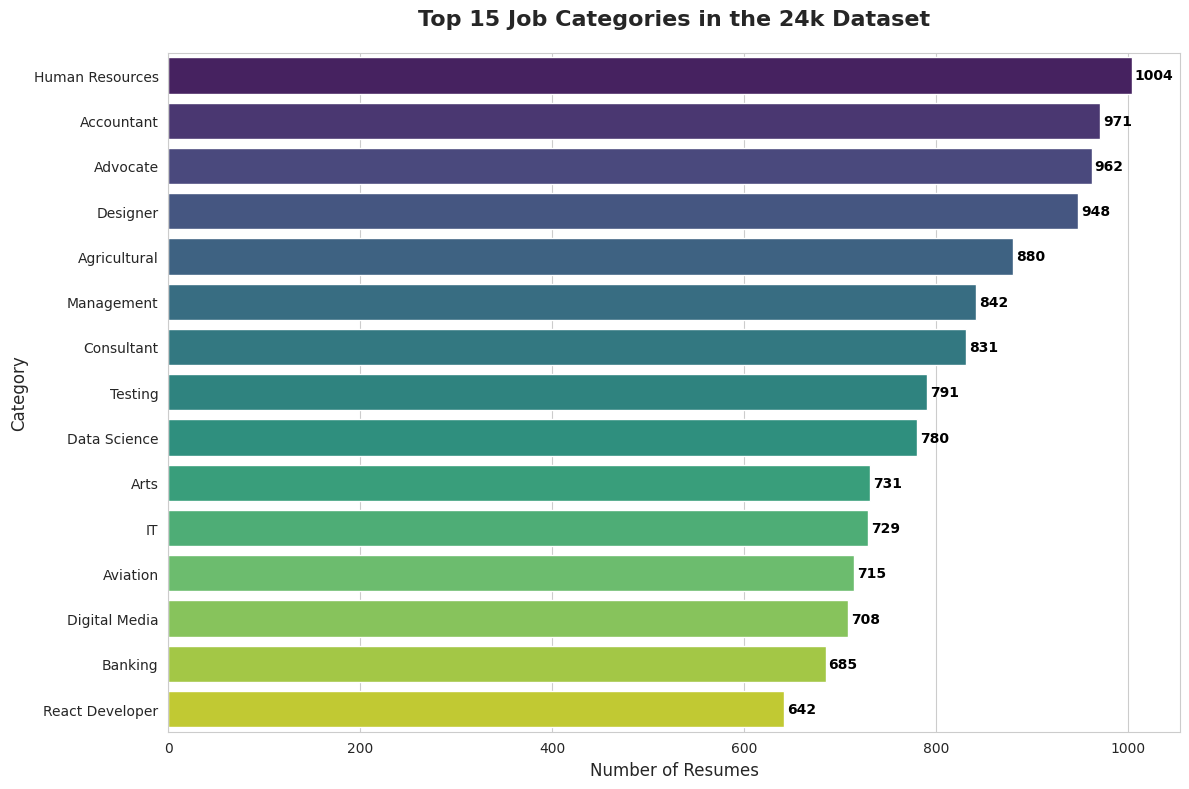

In [16]:
top_categories = df['category'].value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid") 

plot = sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')

plt.title('Top 15 Job Categories in the 24k Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Resumes', fontsize=12)
plt.ylabel('Category', fontsize=12)

for i, v in enumerate(top_categories.values):
    plot.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()

plt.show()

In [17]:
def basic_text_processor(text):
    if not isinstance(text, str):
        return ""
    
    # --- Case Folding ---
    text = text.lower()

    # --- Noise Removal (Cleaning) ---
    text = re.sub(r'\S*@\S*\s?', '', text) 
    text = re.sub(r'http\S+', '', text)  
    
    # -- remove phone number --
    text = re.sub(r'\d{7,15}', ' ', text) 
    
    text = re.sub(r'[^a-z\s]', ' ', text)

    # --- Normalization ---
    text = " ".join(text.split())

    # --- Word Tokenization & Re-joining ---
    tokens = text.split()
    
    return " ".join(tokens)

In [18]:
df['processed_text'] = df['text'].apply(basic_text_processor)

print("-" * 30)
print(f" origan Text  :\n{df['text'].iloc[0][:100]}...")
print(f"\n processed Text :\n{df['processed_text'].iloc[0][:100]}...")

------------------------------
 origan Text  :
jessica claire montgomery street san francisco ca 94105 555 432 1000 professional summary grew up th...

 processed Text :
jessica claire montgomery street san francisco ca professional summary grew up the oldest of sibling...


In [19]:
print(len(df))

22242


In [20]:
df = df[df['processed_text'] != ""]

In [21]:
print(len(df))

22242


In [22]:
df = df[df['processed_text'].str.split().str.len() > 15]

In [23]:
print(len(df))

22227


In [24]:
df = df.drop_duplicates(subset=['processed_text'], keep='first')

In [25]:
print(len(df))

22160


In [26]:
chunk_size = 500
chunk_overlap = 125 
custom_separators = [" ", ""] 

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separators=custom_separators,
    is_separator_regex=False
)

print(f"Processing {len(df)} cleaned resumes using the Hybrid/ID-based system...")

Processing 22160 cleaned resumes using the Hybrid/ID-based system...


In [27]:
all_processed_chunks = []

for index, row in df.iterrows():
    clean_text = str(row['processed_text'])
    
    row_chunks = text_splitter.split_text(clean_text)
    
    meta = {
        "candidate_id": f"CV_{index}", 
        "category": str(row['category'])
    }
    
    for i, chunk in enumerate(row_chunks):
        all_processed_chunks.append({
            "id": f"cv_{index}_chunk_{i}",
            "text": chunk,
            "metadata": meta
        })

In [28]:
model = SentenceTransformer('all-MiniLM-L6-v2')

db_path = "/kaggle/working/my_vector_db"
client = chromadb.PersistentClient(path=db_path)
collection = client.get_or_create_collection(name="cv_matching")

if collection.count() == 0:
    documents = [item['text'] for item in all_processed_chunks]
    metadatas = [item['metadata'] for item in all_processed_chunks]
    ids = [item['id'] for item in all_processed_chunks]

    print("Generating Embeddings (This might take a while)...")
    embeddings = model.encode(documents, show_progress_bar=True).tolist()
    print("Embeddings generated successfully!")
else:
    print(f"Database already contains {collection.count()} items. Skipping embedding generation.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating Embeddings (This might take a while)...


Batches:   0%|          | 0/7726 [00:00<?, ?it/s]

Embeddings generated successfully!


In [29]:
if collection.count() == 0:
    batch_size = 5000
    total_chunks = len(all_processed_chunks)
    
    print(f"Uploading to ChromaDB (Total chunks: {total_chunks})...")
    for i in range(0, total_chunks, batch_size):
        batch_end = min(i + batch_size, total_chunks)
        collection.add(
            embeddings=embeddings[i:batch_end],
            documents=documents[i:batch_end],
            metadatas=metadatas[i:batch_end],
            ids=ids[i:batch_end]
        )
        print(f" Uploaded batch from {i} to {batch_end}")
    print("All data stored successfully in ChromaDB!")
else:
    print(f"Database already contains {collection.count()} items.")

Uploading to ChromaDB (Total chunks: 247227)...
 Uploaded batch from 0 to 5000
 Uploaded batch from 5000 to 10000
 Uploaded batch from 10000 to 15000
 Uploaded batch from 15000 to 20000
 Uploaded batch from 20000 to 25000
 Uploaded batch from 25000 to 30000
 Uploaded batch from 30000 to 35000
 Uploaded batch from 35000 to 40000
 Uploaded batch from 40000 to 45000
 Uploaded batch from 45000 to 50000
 Uploaded batch from 50000 to 55000
 Uploaded batch from 55000 to 60000
 Uploaded batch from 60000 to 65000
 Uploaded batch from 65000 to 70000
 Uploaded batch from 70000 to 75000
 Uploaded batch from 75000 to 80000
 Uploaded batch from 80000 to 85000
 Uploaded batch from 85000 to 90000
 Uploaded batch from 90000 to 95000
 Uploaded batch from 95000 to 100000
 Uploaded batch from 100000 to 105000
 Uploaded batch from 105000 to 110000
 Uploaded batch from 110000 to 115000
 Uploaded batch from 115000 to 120000
 Uploaded batch from 120000 to 125000
 Uploaded batch from 125000 to 130000
 Uploaded

In [30]:
target_category = "Data Science"
job_description = "Data scientist proficient in Python, SQL, and data visualization using Tableau."

query_vector = model.encode([job_description]).tolist()

results = collection.query(
    query_embeddings=query_vector,
    n_results=3,
    where={"category": target_category} 
)

print(f"\n--- Simple Skills Search Results (Category: {target_category}) ---")
for i in range(len(results['documents'][0])):
    print(f"\nRank #{i+1}")
    print(f"Match Confidence (Distance): {results['distances'][0][i]:.4f}")
    print(f"Candidate ID: {results['metadatas'][0][i]['candidate_id']}") 
    print(f"Snippet: {results['documents'][0][i][:200]}...")


--- Simple Skills Search Results (Category: Data Science) ---

Rank #1
Match Confidence (Distance): 0.5457
Candidate ID: CV_2282
Snippet: coding skills in python numpy pandas and machine learning related libraries effective data visualization skills with tools like matplotlib bokeh seaborn qliksense and tableau built several web applica...

Rank #2
Match Confidence (Distance): 0.5499
Candidate ID: CV_15564
Snippet: skills in python numpy pandas and machine learning related libraries effective data visualization skills with tools like matplotlib bokeh seaborn qliksense and tableau built several web applications u...

Rank #3
Match Confidence (Distance): 0.5534
Candidate ID: CV_15464
Snippet: coding skills in python numpy pandas and machine learning related libraries effective data visualization skills with tools like matplotlib bokeh seaborn qliksense and tableau built several web applica...
